## **Facebook Metrics Exploratory Data Anaylsis**

Commencing the initial clean-up on the data and explore what can be done with the data.

Start by looking for any numerical outliers as well as plotting out some basic information from the data. Based on these plots and the domain knowledge I have, I'll begin making a plan as to how I wish to further analyze the data. 

The goal of this EDA is to understand how different features relate to each other and begin to consider which key features I'd like to pursue first in my analysis of the data. At the end of this report, there should be a good understanding of how the Facebook metrics data is distributed.

Data retrieved from [UC Irvine Machine Learning Repository](https://archive.ics.uci.edu/dataset/368/facebook+metrics). Facebook performance metrics of a renowned cosmetic's brand Facebook page. The data is related to posts' published during 2014. Metrics donated 08/04/2016. This dataset is licensed under a [Creative Commons Attribution 4.0 International](https://creativecommons.org/licenses/by/4.0/legalcode), (CC BY 4.0) license which allows for the sharing and adaptation of the datasets for any purpose, provided that the appropriate credit is given.

Additional Variable Information: it includes seven (7) features known prior to post publication and twelve (12) features for evaluating post impact.

**Citation:** (Moro et al., 2016) S. Moro, P. Rita and B. Vala. Predicting social media performance metrics and evaluation of the impact on brand building: A data mining approach. Journal of Business Research, Elsevier, In press.
 
Available at: https://dx.doi.org/10.1016/j.jbusres.2016.02.010

In [1]:
#As always, let's begin with imports.
#Importing pandas and numpy for our numerical analysis
#Importing pyplot and seaborn in order to visualize the data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
#Loading the data
#Used sep= to correct error read_csv as 1 column
fbmetrics_df = pd.read_csv('C:/Users/winni/Fb-Metrics-Modeling/Data/D@ta/dataset_Facebook.csv', sep=";")

In [3]:
#Begin exploring the data by using info() function to get reminder of what data is present, number of rows/columns, data types, etc.
fbmetrics_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   Page total likes                                                     500 non-null    int64  
 1   Type                                                                 500 non-null    object 
 2   Category                                                             500 non-null    int64  
 3   Post Month                                                           500 non-null    int64  
 4   Post Weekday                                                         500 non-null    int64  
 5   Post Hour                                                            500 non-null    int64  
 6   Paid                                                                 499 non-null    float64
 7   Lifetime

In [4]:
#Replacing the space in column names with underscores
fbmetrics_df.columns = fbmetrics_df.columns.str.replace(' ', '_')
print(fbmetrics_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   Page_total_likes                                                     500 non-null    int64  
 1   Type                                                                 500 non-null    object 
 2   Category                                                             500 non-null    int64  
 3   Post_Month                                                           500 non-null    int64  
 4   Post_Weekday                                                         500 non-null    int64  
 5   Post_Hour                                                            500 non-null    int64  
 6   Paid                                                                 499 non-null    float64
 7   Lifetime

### **rename columns ... to do ASAP**

In [ ]:
#Shortening some column names to make it easier to use in subsequent queries
# df = df.rename(columns={'old_name1': 'new_name1', 'old_name2': 'new_name2'})

In [5]:
#Find the number of each object in the 'Type' column
fbmetrics_df['Type'].value_counts()

Type
Photo     426
Status     45
Link       22
Video       7
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='Type'>

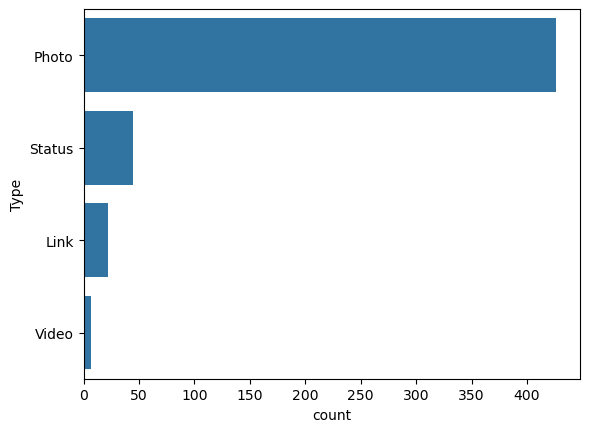

In [6]:
# seaborn countplot of the categories in a particular column
sns.countplot(fbmetrics_df['Type'])

In [ ]:
#Finding initial relationships between columns in the dataset.
corr = fbmetrics_df.corr(numeric_only=True)

,Page_total_likes,Category,Post_Month,Post_Weekday,Post_Hour,Paid,Lifetime_Post_Total_Reach,Lifetime_Post_Total_Impressions,Lifetime_Engaged_Users,Lifetime_Post_Consumers,Lifetime_Post_Consumptions,Lifetime_Post_Impressions_by_people_who_have_liked_your_Page,Lifetime_Post_reach_by_people_who_like_your_Page,Lifetime_People_who_have_liked_your_Page_and_engaged_with_your_post,comment,like,share,Total_Interactions
Page_total_likes,1.000000,-0.091142,0.941192,-0.005401,-0.143807,0.005341,-0.083245,-0.102540,-0.111922,-0.149129,-0.128240,-0.096109,-0.060516,0.033699,0.031891,0.053276,-0.004859,0.045231
Category,-0.091142,1.000000,-0.127690,-0.053239,-0.107383,-0.022474,-0.142073,-0.094368,0.003392,-0.031172,-0.149443,-0.047803,-0.104456,0.021569,0.027842,0.126786,0.149211,0.127307
Post_Month,0.941192,-0.127690,1.000000,0.017050,-0.176390,-0.018934,-0.102506,-0.101616,-0.115898,-0.147083,-0.142829,-0.094624,-0.092012,0.010956,0.006174,0.025633,-0.021859,0.018362
Post_Weekday,-0.005401,-0.053239,0.017050,1.000000,0.045857,-0.001963,-0.050155,-0.033674,-0.048382,-0.029602,-0.021565,-0.046442,-0.068741,0.001144,-0.077209,-0.082322,-0.048713,-0.081049
Post_Hour,-0.143807,-0.107383,-0.176390,0.045857,1.000000,-0.069464,0.003338,0.012747,0.003879,0.012222,0.078759,0.038892,0.052412,0.038011,0.000922,-0.024523,-0.058680,-0.027421
Paid,0.005341,-0.022474,-0.018934,-0.001963,-0.069464,1.000000,0.146631,0.062564,0.117014,0.097679,0.097462,0.003211,0.110043,0.054163,0.075761,0.110694,0.076821,0.107739
Lifetime_Post_Total_Reach,-0.083245,-0.142073,-0.102506,-0.050155,0.003338,0.146631,1.000000,0.694926,0.570629,0.477908,0.324362,0.322254,0.743053,0.400756,0.427155,0.545185,0.456312,0.538597
Lifetime_Post_Total_Impressions,-0.102540,-0.094368,-0.101616,-0.033674,0.012747,0.062564,0.694926,1.000000,0.368553,0.315201,0.226081,0.850787,0.651933,0.323843,0.316612,0.345091,0.286829,0.343358
Lifetime_Engaged_Users,-0.111922,0.003392,-0.115898,-0.048382,0.003879,0.117014,0.570629,0.368553,1.000000,0.968213,0.676840,0.260346,0.612080,0.839279,0.505806,0.569565,0.531261,0.572159
Lifetime_Post_Consumers,-0.149129,-0.031172,-0.147083,-0.029602,0.012222,0.097679,0.477908,0.315201,0.968213,1.000000,0.706666,0.222941,0.503847,0.813510,0.334621,0.349152,0.343048,0.354502


<Axes: >

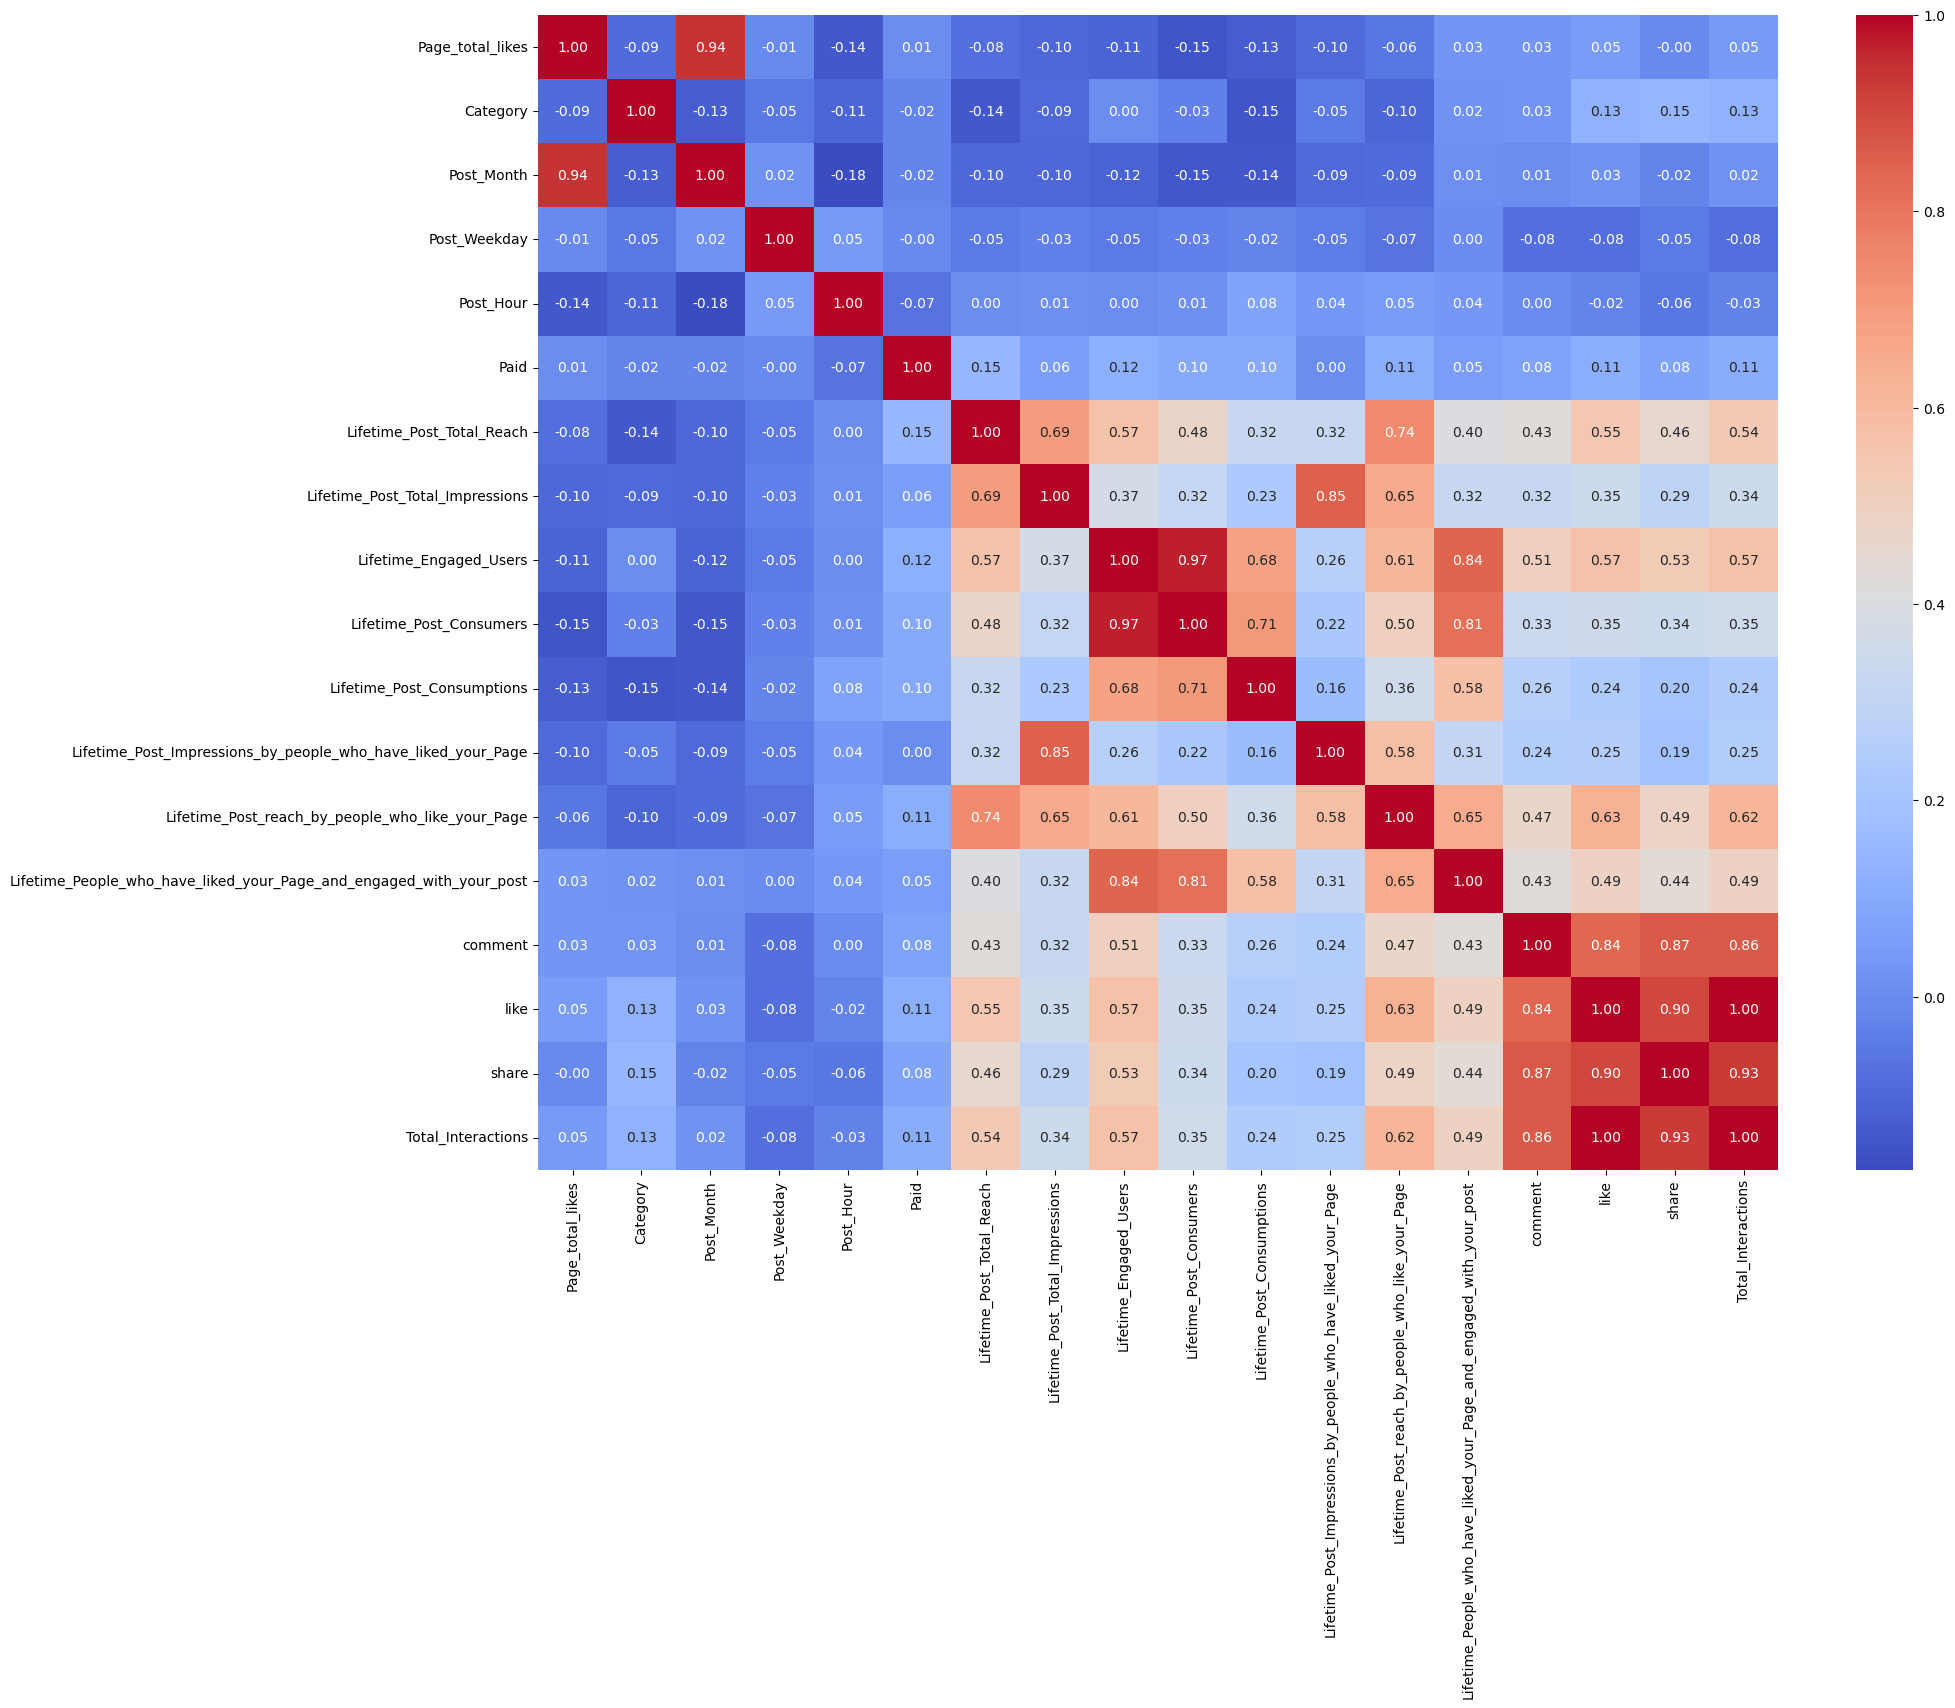

In [ ]:
#Finding initial relationships between columns in the dataset via heatmap
#Adding plt.figure(figsize=(20,15)) to enhance size and readability --> figsize as a tuple
corr = fbmetrics_df.corr(numeric_only=True)
plt.figure(figsize=(20,15))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')

In [ ]:
# Using head() function to view first few rows of data and get a better sense of what we're working with.
fbmetrics_df.head()

### The following columns are defined in the source paper as:
<br>
Name - Definition

In [ ]:
# Using shape function to return tuple of number of rows and columns in the DataFrame.
print("Shape:", fbmetrics_df.shape)

##### Per the source paper, the top feature of **Category** is a manual content chaacterization: <u>*action*</u> (special offers & contests), <u>*product</u>* (direct advertisement, explicit brand content), <u>*inspiration*</u> (non-explicit brand related content)

In [ ]:
# Using value_counts() function to gain more insights into this vaguely worded column "Category"
fbmetrics_df["Category"].value_counts()

##### The source paper also lists the following columns as features used in modeling ...
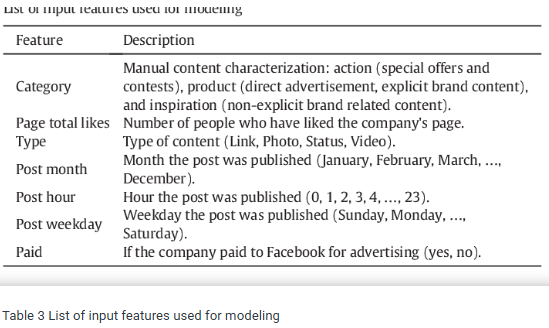

In [ ]:
# Using describe() function and rounding output as two (2) decimal points. 
# Output is basic descriptive and statistics for each columns.
fbmetrics_df.describe().round(2)

##### possibly move df.dropna() to transformation ipynb (see below)

In [ ]:
#consider adding to transformation ipynb
# text here
fbmetrics_df.dropna()

### **<p style="text-align:center;">Target = Total Interactions (int64)**

## Initial Thoughts

Data Types ... how many of each... why want to look at them

Start getting counts of the data and look at the distribution of values. Then can assess how these features correlate/compare to `Total_Interactions`, our target variable. Next look for any initial insights that can be made from a simple 2-D analysis of the data.

First analysis will be with bar charts. `Total_Interactions` won't be included because it is the target. Adding it could skiws some of the initial analysis and it just doesn't make sense to include latest price in our bar charts.

A separate bar chart will be made for `Type` as it is the only object data type in the DataFrame. Based on that bar chart, would most likely convert the data type to string or integer. This should ensure the data works well in the model.

Also want to examine the columns that have Non-Null Counts less than 500. Might be able to drop some of those columns if irrelevant.

Another comparison would be between the columns that have similar names (i.e. 'Lifetime Post Total Reach' vs 'Lifetime Post Reach by people who like your page')

In [ ]:
#Create a function that can count columns and their values.
def count_column(fbmetrics_df,col_list):
    count = {}
    for elem in col_list:
        count(elem) == fbmetrics_df[elem].value_counts()
    return count

#Dropping the target column 'Total Interactions
columns_to_count = fbmetrics_df.columns
columns_to_count = columns_to_count.drop(['Total Interactions'])
fb_string_counts = count_column(fbmetrics_df, columns_to_count)

In [ ]:
plt.figure(figsize = (15,40))


In [ ]:
#Expanding on the barchart we want to look at the breakdown

fig, ax = plt.subplots(figsize = (15,13))


## Initial Impressions

The data 

Missing data points

Outliers

Range



## Numerical Interpretations

Lets look at some of the numerical information that is present in the data. 

Reminder that the following columnns have the type int: 
`name`, `h_name`, `o_name`, `c_name`, `key`.

The following columns have the type float:
'name`, `h_name`, `o_name`, `c_name`, `key`.

Distribution
pairplots and a heatmap to find some initial correlations.

Next examine how each of the features compare in # ranges as box plots to get a sense for how much a certain feature may weigh up against the target.

Scatterplots not useful for the aforementioned data because none of it is really continuous. Most of it is going to be discrete and categorical.

In [ ]:
laptop_df.describe()

interesting... let's see where mean, median & mode take us

In [ ]:
#Lets plot out the distribution of our prices and take a look
price_median = round(laptop_df['latest_price'].median(),2)
fig = plt.figure(figsize=(12,12))


<br>
observation

In [ ]:
#Look at the pairplots, see if we can find any obvious correlations
_ = sns.pairplot(laptop_df)

<br>
From this pairplot, nothing jumps out at me immediately. It definitely feels like the data is distributed pretty fairly across all of the features. Maybe a heatmap can tell us more.

In [ ]:
#Utilize heatmaps as another way of visualizing
plt.figure(figsize = (30,20))
sns.set(font_scale = 2)
sns.heatmap(laptop_df.corr(), annot=True);

<br>
With this we can definitely get a lot more imformation. While the data is categorical we can get a sense for the price combined with other features. It seems there is some correlation with `ssd_gb`,`graphic_card_gb`, and `ram` with our target `latest_price`. Some things that have little correlation (which makes sense) are `warranty` and it seems it has little to do with our price. Surprisingly, there is a slight negative correlation with `hdd_gb` which means the larger hard disk drives do not improve our prices but a larger solid state drive might.


It seems like `hdd_gb` and `ssd_gb` are greatly negatively correlated which makes sense as the presence of one usually denotes the lack of the other as most of the laptops in our dataset do not contain both a ssd and a hdd.

## Looking at Average Prices by Brand and Box Plots

In this section, we want to look at how certain brands price their laptops. We start by looking at the average price before plotting out box plots. It could be a sign that certain brands hold more value over others and there may be some interesting pricing distributions. 

Additionally, we want to compare the ranges of the prices for each of our features so we will be creating some box plots that look at these price ranges. All that information will be below.


In [ ]:
#average price by brand
#Lets look at the average price by brand first and see what we get
laptop_brand_prices = laptop_df[['brand','latest_price']]
laptop_average_brand = laptop_brand_prices.groupby(by = 'brand').agg('mean')
laptop_average_brand.sort_values(by = 'latest_price', ascending = False)

In [ ]:
#Create barplot with the branding price that we created earlier. 
#This might give us some insight into how prices are distributed and some outliers to look out for.
sns.set(font_scale = 1)

In [ ]:
#There is only one laptop with a price greater than $5,000 so lets look at those specs.
laptop_df[laptop_df['latest_price'] > 5000]

<br>
As stated in the previous analysis, this one outlier makes sense given its specs. We are keeping it in. 

Otherwise, it seems most of the brands fall into expected priceranges. Alienware is slightly more expensive as it is marketed as a more expensive computer and Apple also falls in that category. For the most part, other brands stay within their price bracket with a few high-end models outside of that. Lets look at some more data such as model comparison.

In [ ]:
#This plot is somewhat wild, apologies



This model data is kind of messy so it is difficult to get any specific data out of it. We see that "Missing" shows up again and we have an issue with its data, otherwise I am reluctant to use this box plot as a means of analysis.

In [ ]:
#We looked at brand and model so we can drop those, 
#We also drop latest price because we don't want to include that in our analysis
laptop_df_noprice = laptop_df.drop(['latest_price','brand', 'model'], axis = 1)

In [ ]:
#Box plots for all of our features, analysis at the end
plt.subplots_adjust(hspace = 1.5)

## Final Impressions

So far, we have seen that there seems to be little variance in price when it comes to our price ranges. Every feature for the most part falls in-line with its competitors. We do see that for `processor_name` that Corei9 sits above the other processors which makes sens as it is one of the more powerful processors on the market and is part of our Asus Zephyr outlier from earlier. Most of the `processor_gnrtn` sits in the same range except for the 12th which sits above the rest but with no outliers. 

It would seem that each individual feature does not cause a large amount of variance in the price and that it would be a combination of these features which cause the price increases. I am reluctant to remove any specific features for the time being. It may be useful to recreate some of the data as binary (such as `warranty`) in order to simplify the feature analysis and to remove some data such as `msoffice` which does not seem to add to our analysis. I would like to reduce the amount of groups in `display_size` and simply round these numbers to the nearest size so taht the data is more compact as a difference of 0.1-0.2" is due to how these sizes are displayed on the product website and may not be indicative of any significant differences.

The exploration has told me more about my data and how I want to treat it moving forward. What may be useful is taking a clustering approach and giving us a price range given our laptop's specifications or using a GLM in order to perform regression analysis. Further research into our ML models may help us find a better model.